In [152]:
import yfinance
stock_symbol = "AAL"
start_date = "2019-01-01"
end_date = "2024-01-01"

dataframe = yfinance.download(tickers = stock_symbol,
                                 start = start_date,
                                 end = end_date)
dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAL,AAL,AAL,AAL,AAL
Date,,,,,
2019-01-02,31.963158,32.130454,30.555912,30.959388,5229500
2019-01-03,29.581665,31.343182,28.351556,31.185728,16822000
2019-01-04,31.530161,31.579365,29.916256,29.955621,9369600
2019-01-07,32.425682,32.947247,30.742892,31.480957,8010700
2019-01-08,31.904110,33.114541,31.687613,32.829154,7107700
...,...,...,...,...,...
2023-12-22,14.310000,14.400000,14.210000,14.380000,25169900
2023-12-26,14.110000,14.260000,14.040000,14.250000,22157900


In [153]:
import numpy

In [154]:
X = numpy.asarray(dataframe[["Open", "High", "Low", "Volume"]])

X

array([[3.09593881e+01, 3.21304545e+01, 3.05559124e+01, 5.22950000e+06],
       [3.11857285e+01, 3.13431823e+01, 2.83515559e+01, 1.68220000e+07],
       [2.99556207e+01, 3.15793645e+01, 2.99162563e+01, 9.36960000e+06],
       ...,
       [1.41000004e+01, 1.41800003e+01, 1.39099998e+01, 2.34285000e+07],
       [1.39200001e+01, 1.40400000e+01, 1.38199997e+01, 1.70934000e+07],
       [1.39499998e+01, 1.39700003e+01, 1.36899996e+01, 2.42420000e+07]])

In [155]:
BUY = 1
SELL = 0

dataframe["Buy Or Sell"] = numpy.where(dataframe["Close"].shift(-1) > dataframe["Close"],BUY,SELL)
dataframe

Price,Close,High,Low,Open,Volume,Buy Or Sell
Ticker,AAL,AAL,AAL,AAL,AAL,
Date,,,,,,
2019-01-02,31.963158,32.130454,30.555912,30.959388,5229500,0
2019-01-03,29.581665,31.343182,28.351556,31.185728,16822000,1
2019-01-04,31.530161,31.579365,29.916256,29.955621,9369600,1
2019-01-07,32.425682,32.947247,30.742892,31.480957,8010700,0
2019-01-08,31.904110,33.114541,31.687613,32.829154,7107700,1
...,...,...,...,...,...,...
2023-12-22,14.310000,14.400000,14.210000,14.380000,25169900,0
2023-12-26,14.110000,14.260000,14.040000,14.250000,22157900,0


In [156]:
y = numpy.asarray(dataframe["Buy Or Sell"])

y

array([0, 1, 1, ..., 0, 0, 0])

In [157]:
from sklearn import preprocessing

X = preprocessing.StandardScaler().fit(X).transform(X)

X

array([[ 1.70168417,  1.8047886 ,  1.71384767, -0.92205454],
       [ 1.73457892,  1.69121952,  1.39112503, -0.56742274],
       [ 1.55580357,  1.72529033,  1.62020062, -0.79540273],
       ...,
       [-0.74854258, -0.78467993, -0.72315049, -0.36532009],
       [-0.77470258, -0.80487588, -0.73632671, -0.55912021],
       [-0.77034263, -0.81497378, -0.75535901, -0.34043392]])

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/5, random_state = 0)

X_train.shape

(1006, 4)

In [159]:
X_test.shape

(252, 4)

In [160]:
y_train.shape

(1006,)

In [161]:
y_test.shape

(252,)

In [162]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C = 0.01,
                  solver = "liblinear")
model.fit(X_train, y_train)

LogisticRegression(C=0.01, solver='liblinear')

In [163]:
prediction = model.predict(X_test)

prediction

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0])

In [164]:
estimates_for_all_classes = model.predict_proba(X_test)
estimates_for_all_classes

array([[0.54594224, 0.45405776],
       [0.51891043, 0.48108957],
       [0.54235105, 0.45764895],
       [0.47686465, 0.52313535],
       [0.52346618, 0.47653382],
       [0.56395226, 0.43604774],
       [0.51326939, 0.48673061],
       [0.5020458 , 0.4979542 ],
       [0.58960573, 0.41039427],
       [0.51988535, 0.48011465],
       [0.53974941, 0.46025059],
       [0.49897348, 0.50102652],
       [0.48184045, 0.51815955],
       [0.48356549, 0.51643451],
       [0.50754006, 0.49245994],
       [0.4814837 , 0.5185163 ],
       [0.49948151, 0.50051849],
       [0.4862506 , 0.5137494 ],
       [0.55122758, 0.44877242],
       [0.50124649, 0.49875351],
       [0.48073952, 0.51926048],
       [0.55034259, 0.44965741],
       [0.51442036, 0.48557964],
       [0.54160865, 0.45839135],
       [0.4868075 , 0.5131925 ],
       [0.53863903, 0.46136097],
       [0.49435348, 0.50564652],
       [0.49789252, 0.50210748],
       [0.49502161, 0.50497839],
       [0.51915041, 0.48084959],
       [0.

In [165]:
from sklearn.metrics import jaccard_score

jaccard_score(y_test, prediction)

0.2857142857142857

Text(0, 0.5, 'Actual y')

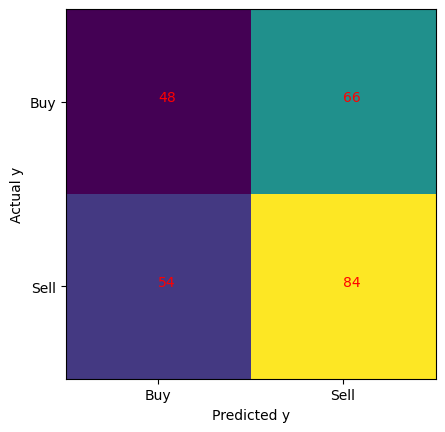

In [167]:
from sklearn.metrics import confusion_matrix

confusion_matrix_results = confusion_matrix(y_test, prediction, labels = [1, 0])

import matplotlib.pyplot as pyplot

pyplot.figure()

pyplot.imshow(confusion_matrix_results)

classes = ["Buy", "Sell"]

tick_marks = numpy.arange(len(classes))

pyplot.xticks(tick_marks, classes)

pyplot.yticks(tick_marks, classes)

import itertools

for row, column in itertools.product(range(confusion_matrix_results.shape[0]),
                                          range(confusion_matrix_results.shape[1])):
    pyplot.text(column, row, format(confusion_matrix_results[row, column]), color = "red")

pyplot.xlabel("Predicted y")
pyplot.ylabel("Actual y")

In [168]:
from sklearn import metrics

metrics.accuracy_score(y_test, prediction)

0.5238095238095238

In [169]:
metrics.recall_score(y_test, prediction)

0.42105263157894735

In [170]:
metrics.precision_score(y_test, prediction)

0.47058823529411764

In [171]:
from sklearn.metrics import log_loss

log_loss(y_test, estimates_for_all_classes)

0.6968457150653135

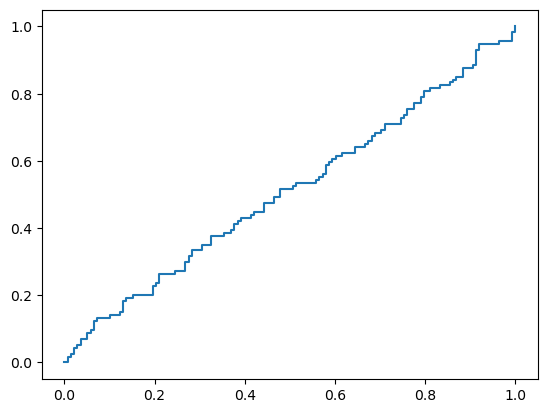

In [173]:
probability_predictions = model.predict_proba(X_test)[::, 1]

false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, probability_predictions)

pyplot.plot(false_positive_rate, true_positive_rate)

pyplot.show()